### <center> Simulating Dynamical Systems

#### What is a Dynamical System?

Dynamical Systems are mathematical systems that evolve in time. They are characterized by an update rule that describes how the system evolves from one time point to the next. First, let's define a discrete time dynamical system

$$
t \in 0,1,\cdots
$$
$$
X_{t+1} = f(X_{t}).
$$

So the state of a system $X_{t}$ is updated at specific time intervals(e.g. yearly, daily, hourly) using a function $f$. 

#### Example of a Discrete Dynamical System

The first dynamical system we will look at is inspired by biology. Consider a bacteria population in a medium with infinite resources. Let $X_t$ be the population of bacteria in the medium at time $t$. If the bacteria double every hour, we can update $X_{t}$ hourly and write 

$$
X_{t+1} = 2 X_t
$$

where $t \in \text{hour 0}, \text{hour 1}, \dots$. 

Now we will use python to simulate this dynamical system and predict bacteria populations in the future. Before starting, note that we will require one more component to fully specify this system, the initial condition. If we don't know the population of the bacteria at time 0 we cannot calculate the population at time 1 and therefore we can't predict the population at time 2 and so on. 

Let's set the initial population of bacteria to 1, so $X_{0} = 1$. 

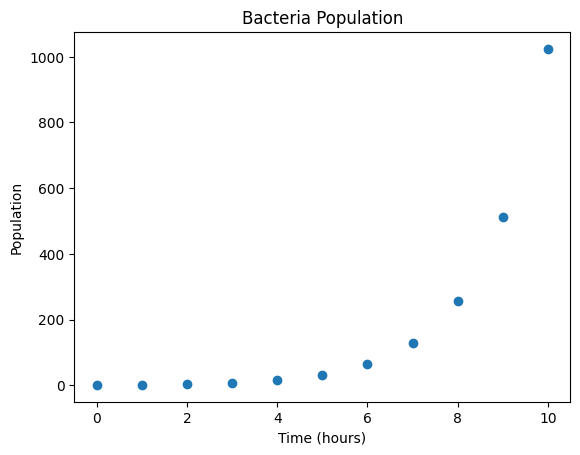

In [10]:
import numpy as np
import matplotlib.pyplot as plt

ts = np.arange(0,10 + 1,1) #We will compute the bacteria population over a ten hour period

xs = np.zeros(len(ts))
xs[0] = 1 #Set the initial condition

for t_index in range(1,len(ts)): 
    xs[t_index] = 2 * xs[t_index - 1]

plt.title('Bacteria Population')
plt.scatter(ts,xs)
plt.xlabel('Time (hours)')
plt.ylabel('Population')
plt.show()

This model is good for the growth phase of bacteria, but it assumes the amount of food available to the bacteria is unlimited. In practice the bacteria population will not grow forever and will plateau as the amount of food in the environment declines. We can adjust our model to reflect this, 

$$
X_{t+1} = X_{t} + X_{t}\left(1 - \frac{X_{t}}{N}\right)
$$

where the term $\left(1 - \frac{X_{t}}{N}\right)$ will damp the growth of $X_t$ as it gets close to $N$. The parameter $N$ represents the "carrying capacity" of the environment, e.g. the number of bacteria the environment can support. Let's set $N = 100$ and simulate this new system. 

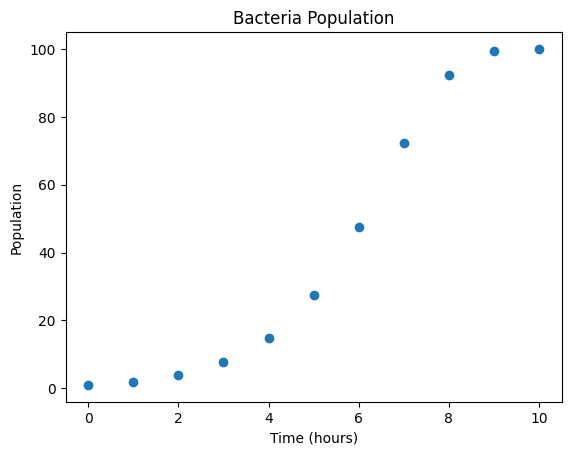

In [11]:
ts = np.arange(0,10 + 1,1) #We will compute the bacteria population over a ten hour period

xs = np.zeros(len(ts))
xs[0] = 1 #Set the initial condition

N = 100

for t_index in range(1,len(ts)): 
    xs[t_index] = xs[t_index - 1] + xs[t_index - 1] * (1 - xs[t_index - 1]/N)

plt.title('Bacteria Population')
plt.scatter(ts,xs)
plt.xlabel('Time (hours)')
plt.ylabel('Population')
plt.show()

This simulation "looks like" the original model near the beginning but begins to plateau near the carrying capacity. 

Observing the graph we see that we only know the number of bacteria each hour, but in reality bacteria reproduce continuously. This raises the question, "Can we create a dynamical system in continuous time with the same properties as our discrete time dynamics?"

First lets examine 
$$
X_{t+1} = 2X_{t} 
$$
and rewrite this system as

$$
X_{t+1} = X_{t} + X_{t}.
$$

We will further introduce a variable $\Delta t$ which is the length of time between successive time points. In our case $\Delta t = \text{1 hour}$. 
Rewriting yields

$$
X_{t+1} - X_{t} = X_{t} \cdot \Delta t
$$

and dividing through by $\Delta t$ yields

$$
\frac{X_{t+1} - X_{t}}{\Delta t} = X_{t}.
$$

We can interpret this expression as telling us the average change in $X_{t}$ over a time interval $\Delta t$ is $X_{t}$. 

Now we take the limit 
$$
\lim_{\Delta t \rightarrow 0} \frac{X_{t+1} - X_{t}}{\Delta t} = \frac{dX(t)}{dt} = X(t).
$$

Therefore the continuous time dynamical system $\frac{dX(t)}{dt} = X(t)$ can be viewed as a limit of our original discrete system as the distance between time points goes to zero. We can solve this system to find an expression for $X(t)$. 

Starting with
$$
\frac{dX(t)}{dt} = X(t)
$$
we can rearrange and integrate both sides with respect to $t$
$$
\frac{dX}{X(t)} = dt
$$

and 

$$
\begin{align*}
\int \frac{dX(t)}{X(t)} = \int dt. 
\end{align*}
$$

Solving the integrals yields

$$
\begin{align*}
\ln(X(t)) &= t + C \\
X(t) &= e^{t + C} = e^{t}e^{C} \\
X(t) = De^{t}
\end{align*}
$$

where $D$ is an unknown constant which we can identify through the initial condition
$$
\begin{align*}
X(0) &= De^{0} \\
1 &= D.
\end{align*}
$$

So we are left with the $X(t) = e^{x}$. Let's now plot this function alongside our discrete time dynamical system above. 




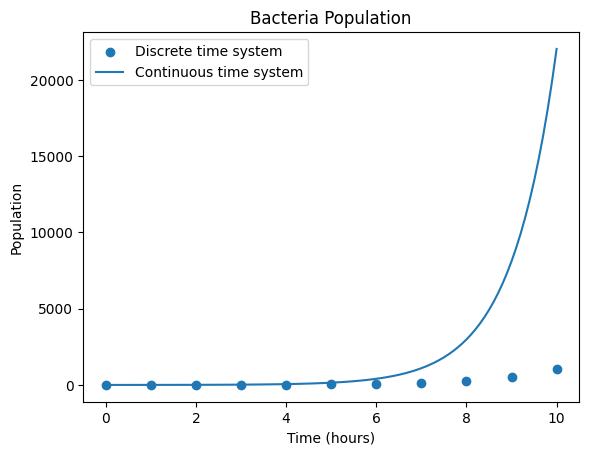

In [17]:
ts = np.arange(0,10 + 1,1) #We will compute the bacteria population over a ten hour period
ts_cont = np.arange(0,10 + 0.1,0.1)

xs = np.zeros(len(ts))
xs[0] = 1 #Set the initial condition

for t_index in range(1,len(ts)): 
    xs[t_index] = 2 * xs[t_index - 1]

plt.title('Bacteria Population')
plt.scatter(ts,xs,label = 'Discrete time system')
plt.plot(ts_cont,np.exp(ts_cont),label = 'Continuous time system')
plt.xlabel('Time (hours)')
plt.ylabel('Population')
plt.legend()
plt.show()

It appears the continuous time dynamical system grows far more quickly than the discrete time system. Why is this? 

We will introduce a parameter $r$ that we call the growth rate. This parameter controls how quickly the population of bacteria grows and can be adjusted for different species of bacteria. If we assume as in our discrete time system that the bacteria population doubles every hour we can find value for $r$ such that $X(t) = X_t$ at each hour. 

Lets consider $X_{t}$ at hour 1. Since our population doubles each hour $X_{1} = 2$ as we started from a single bacteria. Let 

$$
\begin{align*}
X(1) &= X_{1} \\
e^{r} &= 2 \\
\ln(e^{r}) &= \ln(2) \\
r &= \ln(2). 
\end{align*}
$$

So we have derived our growth rate $r = \ln(2)$. Let's plot the two equations again.

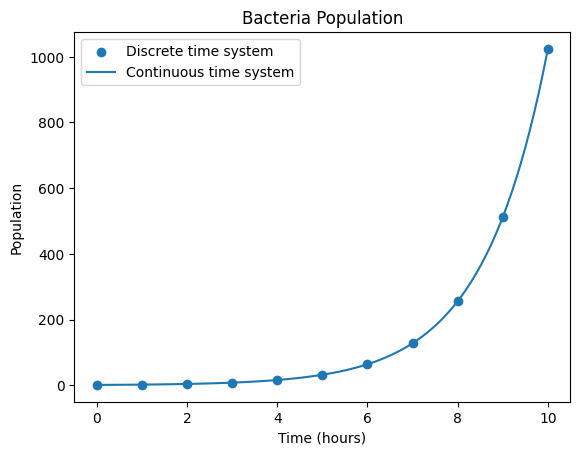

In [26]:
ts = np.arange(0,10 + 1,1) #We will compute the bacteria population over a ten hour period
ts_cont = np.arange(0,10 + 0.1,0.1)

xs = np.zeros(len(ts))
xs[0] = 1 #Set the initial condition

r = np.log(2)

for t_index in range(1,len(ts)): 
    xs[t_index] = 2 * xs[t_index - 1]

cont_time_system = np.exp(r * ts_cont)

plt.title('Bacteria Population')
plt.scatter(ts,xs,label = 'Discrete time system')
plt.plot(ts_cont,cont_time_system,label = 'Continuous time system')
plt.xlabel('Time (hours)')
plt.ylabel('Population')
plt.legend()
plt.show()

We could follow a similar process to derive a continuous time logistic growth equation. However, the expression for $X(t)$ is quite a bit more complicated. We will omit the steps here but the solution to the continuous time logistic growth equation is 

$$
X(t) = \frac{N}{1 + \left(\frac{N - X_0}{X_0}\right) e^{-rt}}
$$

Where $X_{0} = X(0) = 1$.

#### Solvability of Continuous Time Dynamical Systems

In general, continuous time dynamical systems look like 

$$
\begin{align*}
\frac{dX}{dt} &= f(X(t),t) \\
X(0) &= X_{0}
\end{align*}
$$
an update rule given by a differential equation and an initial condition. One would hope we could solve all differential equations algebraically, however this is impossible in general. There are many interesting dynamical systems that don't have an algebraic solution, so how do we solve them? 

We turn to simulation, and derive a discrete time dynamical system that is "close" to our continuous time system.
Then we use the approximation 

$$
\begin{aligned}
\frac{dX}{dt} \approx \frac{X(t+\Delta t) - X(t)}{\Delta t}
\end{aligned}
$$

where we have substituted the concrete time step $\Delta t$ for the infinitesimal time step $dt$. The value of $\Delta t$ controls the error of the approximation. Our finite difference derivative then becomes

$$
\begin{aligned}
\frac{X(t+\Delta t) - X(t)}{\Delta t} = f(X(t),t). 
\end{aligned}
$$. 

We can solve this expression for $X(t + \Delta t)$ to obtain an update formula 

$$
\begin{aligned}
X(t + \Delta t) = X(t) + \Delta t \cdot f(X(t),t) 
\end{aligned}
$$. 

This formula gives us a recursion relation by which we can obtain an approximate solution to $X(t)$ on a grid of time points $[0,\Delta t, 2\Delta t, \dots]$ given a starting point $X(0) = X_0$.

Let's code up this formula to approximation an unsolvable dynamical system 

$$
\begin{align*}
\frac{dX}{dt} &= t - X - X^3 \\
X(0) &= 0. \\
\end{align*}
$$



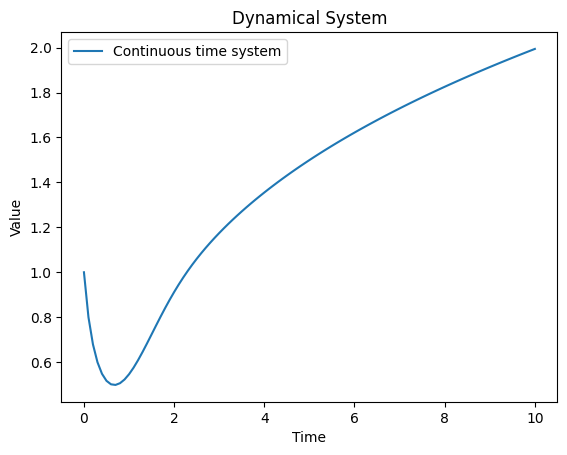

In [42]:
delta_t = 0.1
ts_cont = np.arange(0,10 + delta_t,delta_t)

xs = np.zeros(len(ts_cont))
xs[0] = 1 #Set the initial condition

def f(X,t): 
    return t- X - X**3

for t_index in range(1,len(ts_cont)): 
    x_prev = xs[t_index - 1]
    xs[t_index] = x_prev + delta_t * f(x_prev,ts_cont[t_index -1])

plt.title('Dynamical System')
plt.plot(ts_cont,xs,label = 'Continuous time system')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.show()